<a href="https://colab.research.google.com/github/amoukrim/Python/blob/main/Week3/DailyChallenge/DailyChallenge_w3d4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Daily Challenge : Comprehensive Mobile Price Analysis
@author : Adil MOUKRIM

In [7]:

import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement des données
df = pd.read_csv("/content/train.csv")

# Informations générales et statistiques de base
print("\nDataset Info:\n")
df.info()

print("\nSummary Statistics:\n")
print(df.describe())

print("\nTarget Value Counts:\n")
print(df['price_range'].value_counts())



Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64

In [8]:

# Vérification des valeurs manquantes et des doublons
print("\nMissing Values:\n")
print(df.isnull().sum())
print("aucune valeur manquante n'a été détectée dans le dataset (`df.isnull().sum()`), donc aucune imputation n’a été nécessaire.")
print("\nDuplicate Rows:", df.duplicated().sum())
print("\n Pas de données dupliquées:")



Missing Values:

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64
aucune valeur manquante n'a été détectée dans le dataset (`df.isnull().sum()`), donc aucune imputation n’a été nécessaire.

Duplicate Rows: 0

 Pas de données dupliquées:


In [9]:

features = df.columns.drop("price_range")

for col in features:
    print(f"\n--- Statistics for {col} ---")
    print("Mean:", np.mean(df[col]))
    print("Median:", np.median(df[col]))
    print("Mode:", df[col].mode()[0])
    print("Range:", np.ptp(df[col]))
    print("Variance:", np.var(df[col]))
    print("Std Dev:", np.std(df[col]))
    print("Skewness:", stats.skew(df[col]))
    print("Kurtosis:", stats.kurtosis(df[col]))

print("\n--- ANOVA Test between Features and Price Range ---")
for col in features:
    groups = [df[df['price_range'] == val][col] for val in sorted(df['price_range'].unique())]
    f_stat, p_val = stats.f_oneway(*groups)
    print(f"{col}: F={f_stat:.2f}, p={p_val:.4f}")

print("\nCorrelation with target variable:\n")
print(df.corr()['price_range'].sort_values(ascending=False))



--- Statistics for battery_power ---
Mean: 1238.5185
Median: 1226.0
Mode: 618
Range: 1497
Variance: 192991.81565774983
Std Dev: 439.3083377967573
Skewness: 0.03187454295305568
Kurtosis: -1.224084165725428

--- Statistics for blue ---
Mean: 0.495
Median: 0.0
Mode: 0
Range: 1
Variance: 0.24997499999999545
Std Dev: 0.4999749993749642
Skewness: 0.02000100007500624
Kurtosis: -1.9995999599959997

--- Statistics for clock_speed ---
Mean: 1.52225
Median: 1.5
Mode: 0.5
Range: 2.5
Variance: 0.6655299375000027
Std Dev: 0.8158001823363382
Skewness: 0.17795052935349268
Kurtosis: -1.3231094949498647

--- Statistics for dual_sim ---
Mean: 0.5095
Median: 1.0
Mode: 1
Range: 1
Variance: 0.24990974999999974
Std Dev: 0.4999097418534667
Skewness: -0.03800686085763292
Kurtosis: -1.9985554785277484

--- Statistics for fc ---
Mean: 4.3095
Median: 3.0
Mode: 0
Range: 19
Variance: 18.838709749999897
Std Dev: 4.340358251342843
Skewness: 1.0190463925723268
Kurtosis: 0.27338561771466496

--- Statistics for four_g 

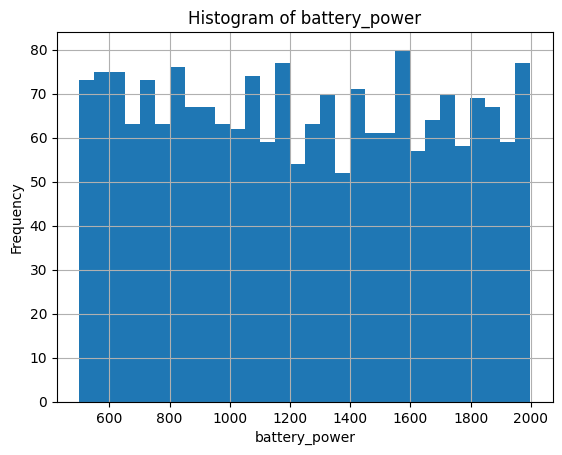

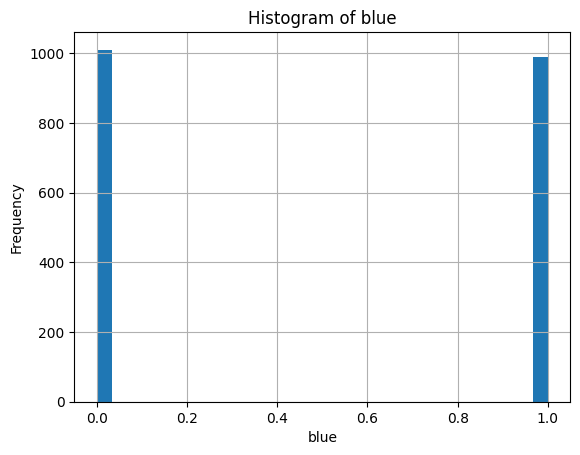

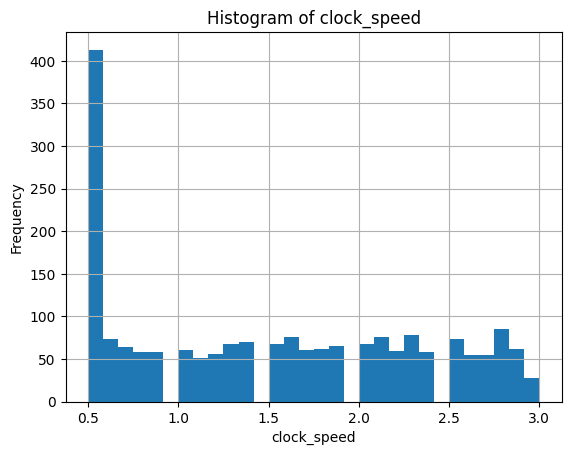

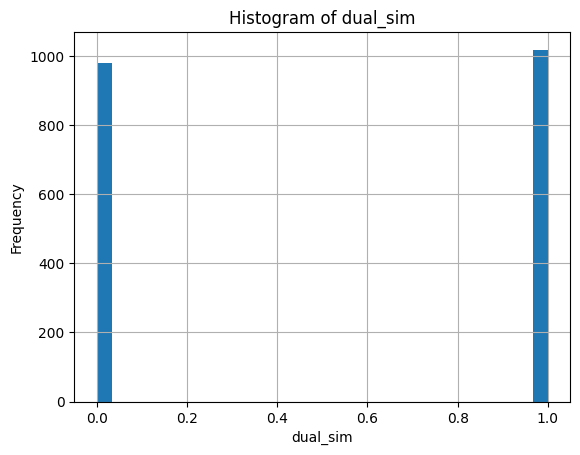

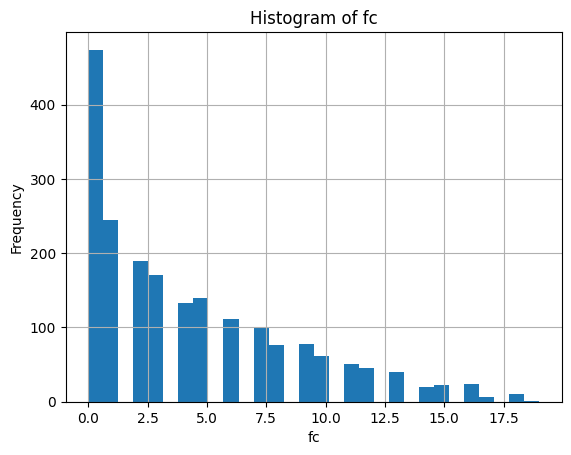

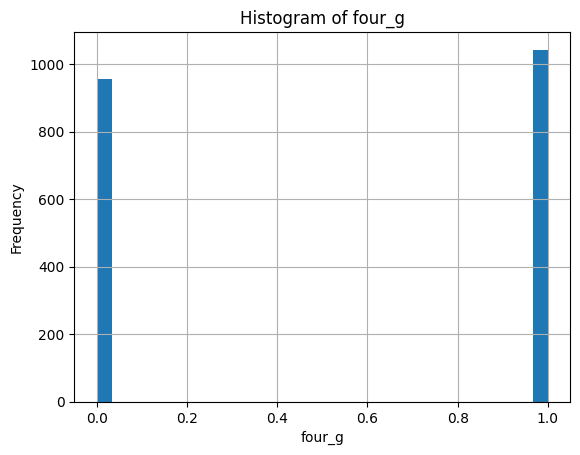

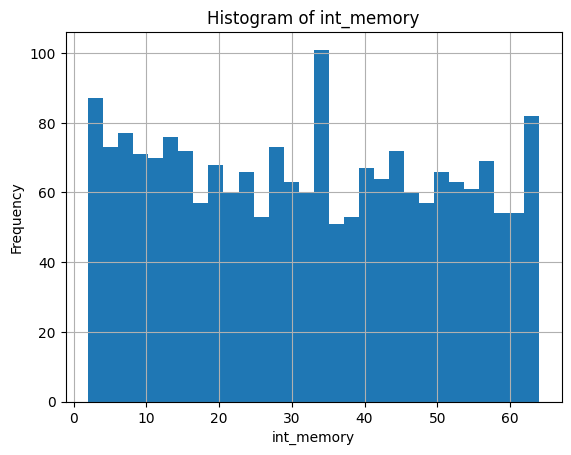

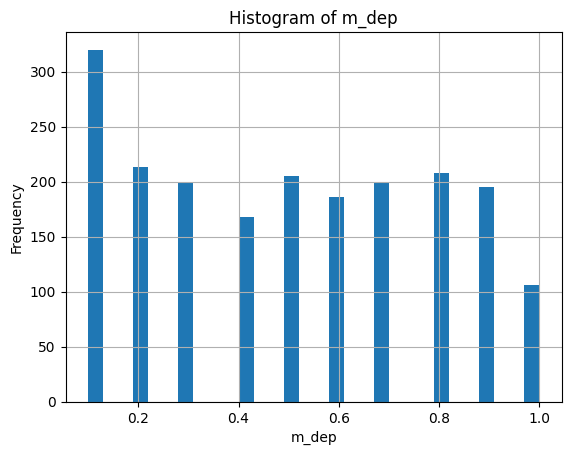

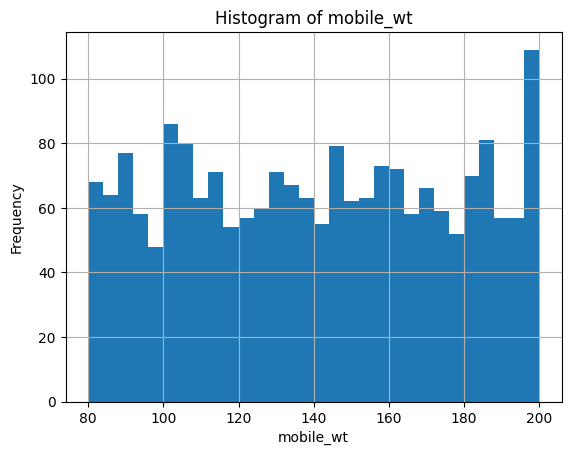

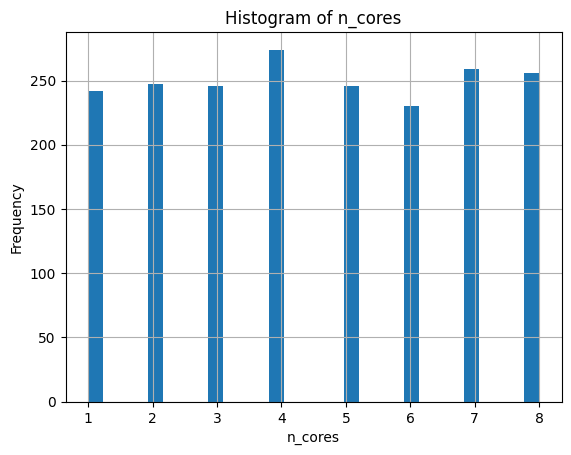

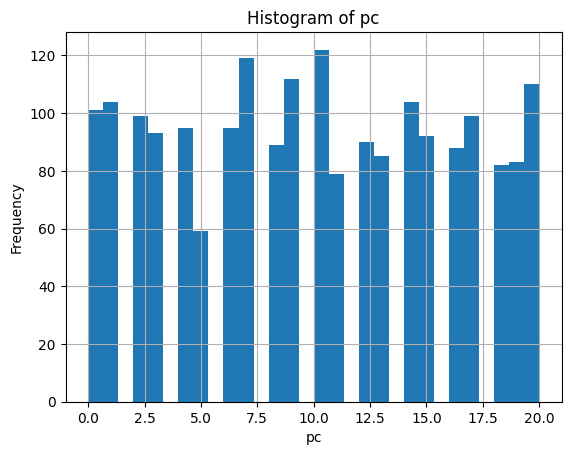

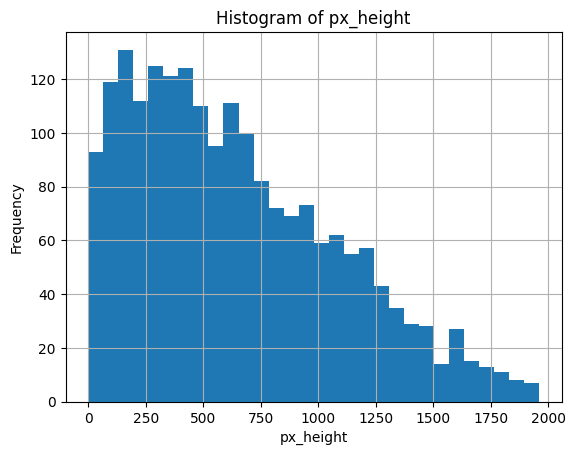

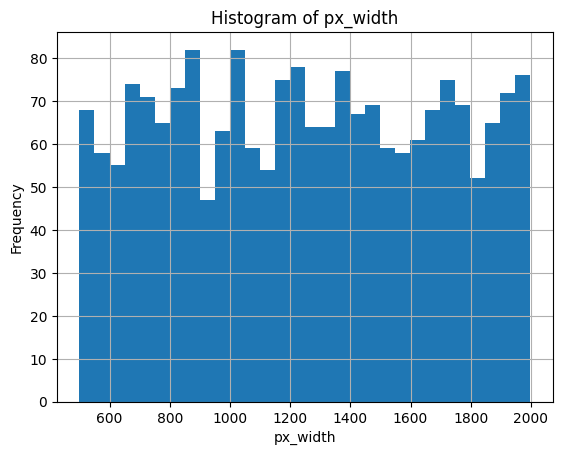

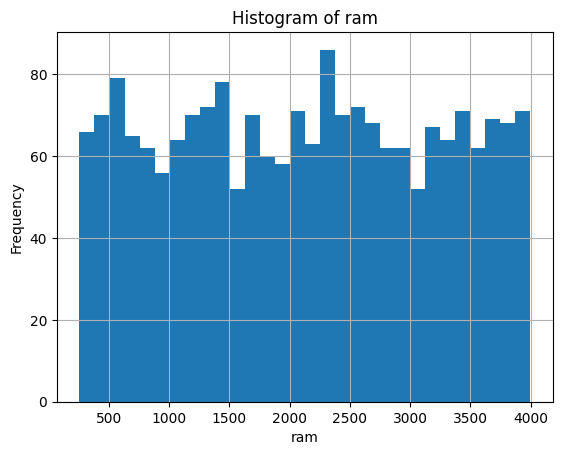

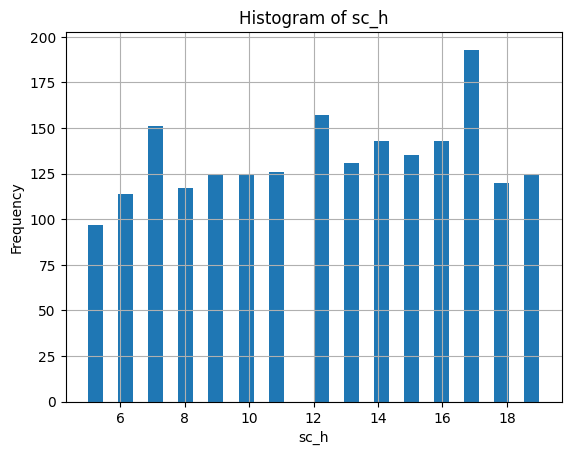

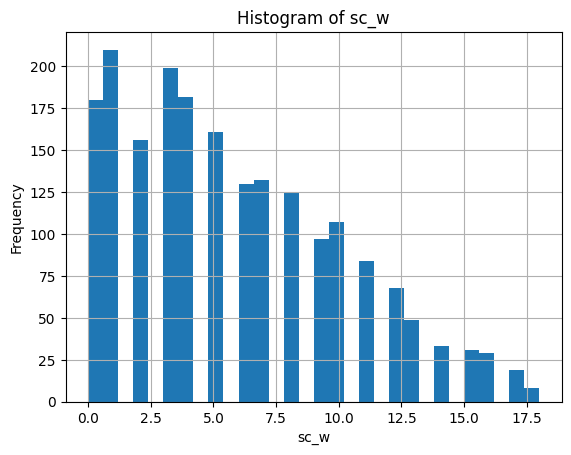

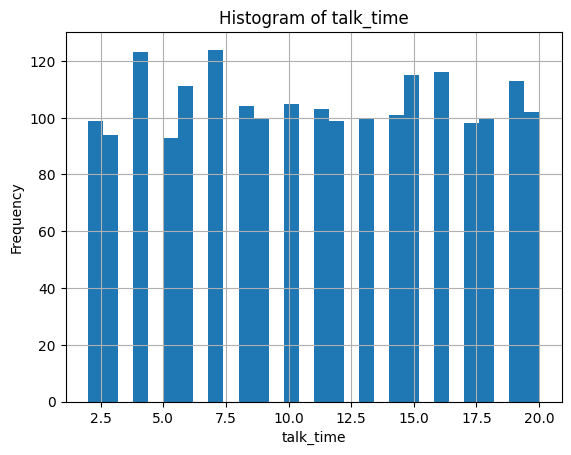

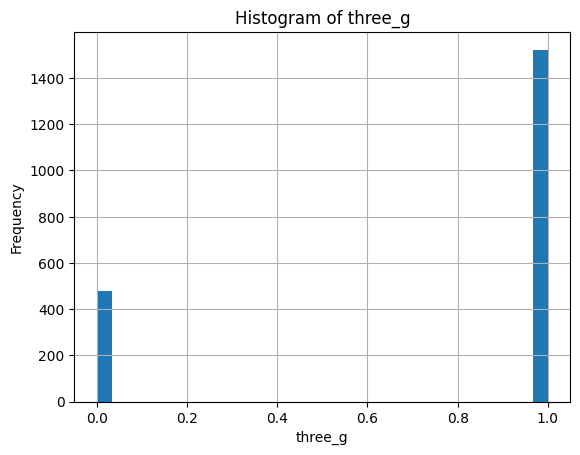

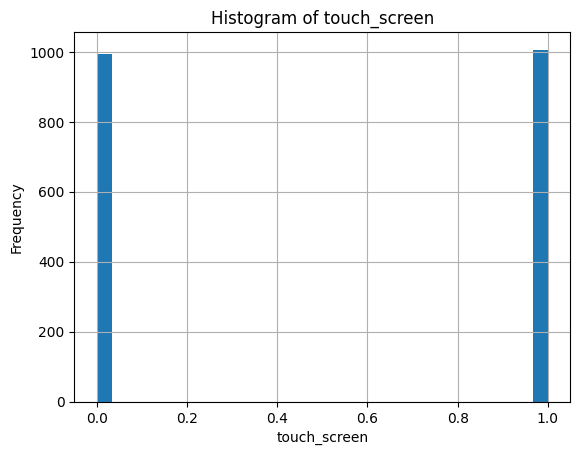

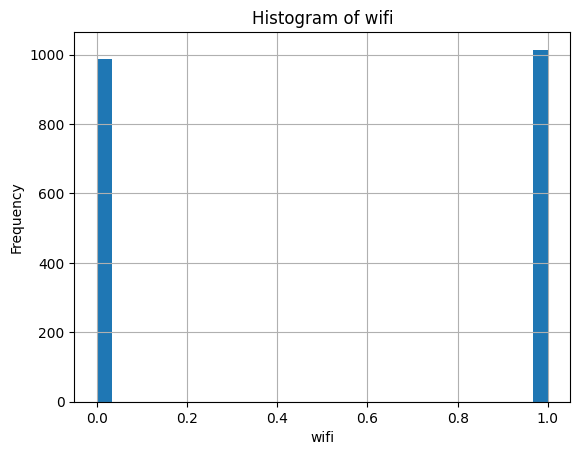

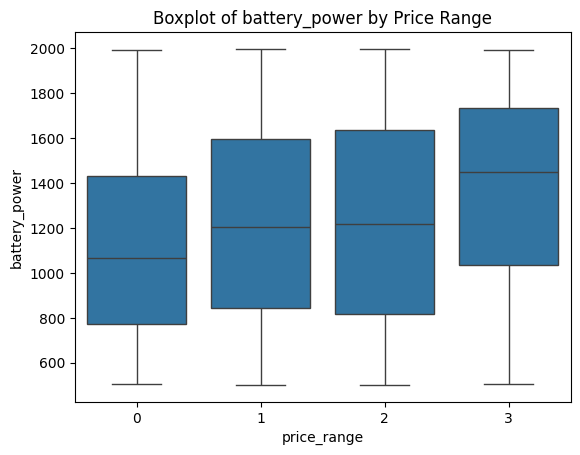

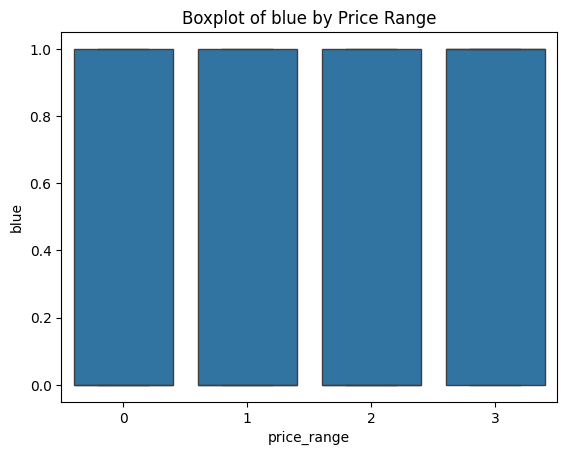

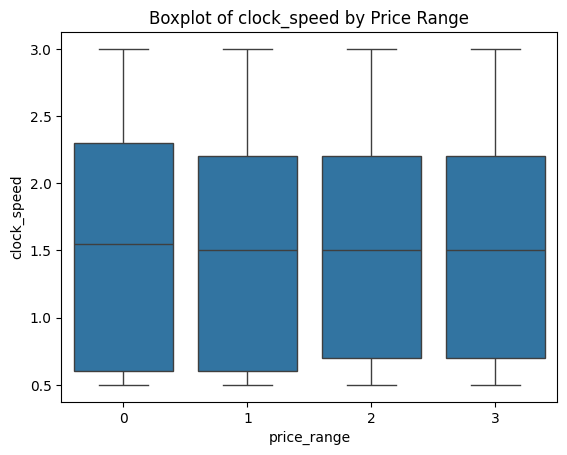

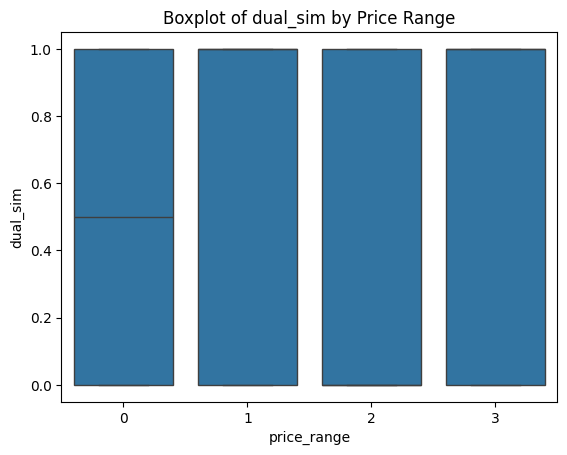

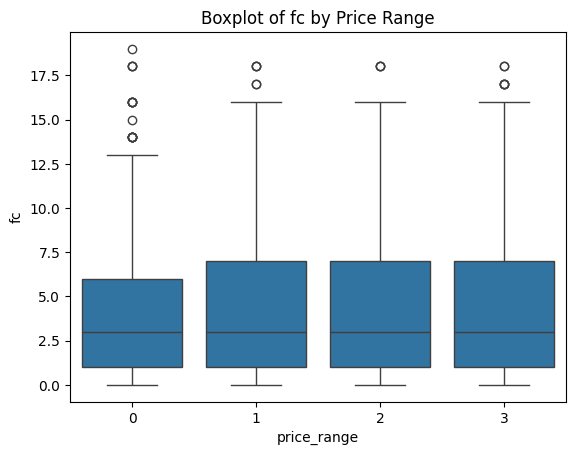

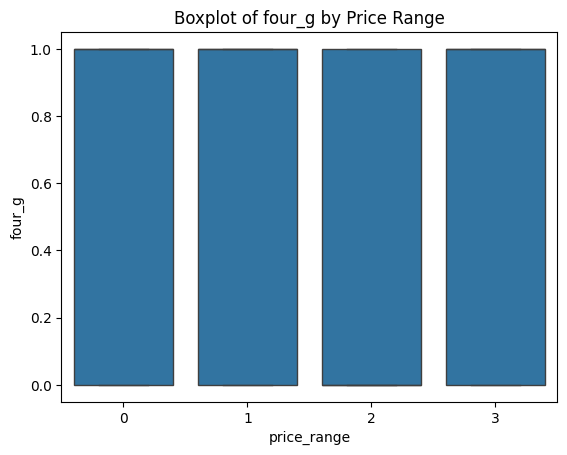

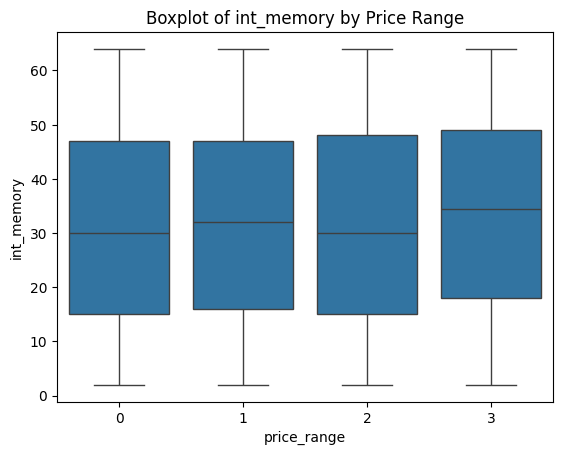

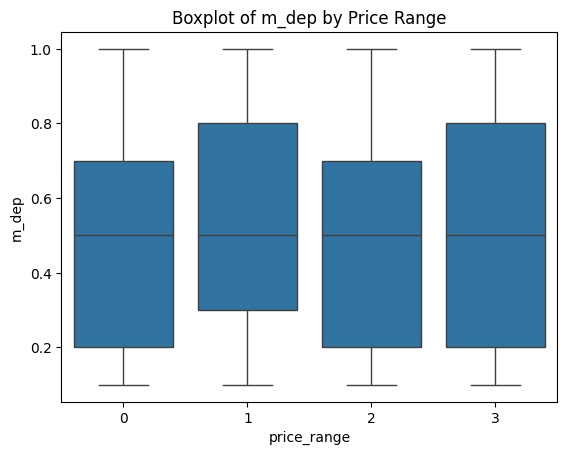

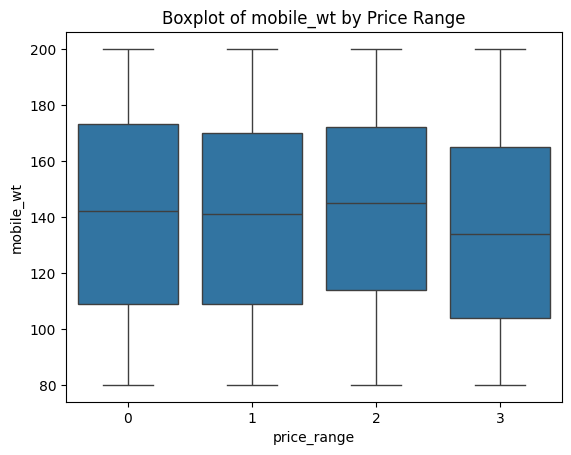

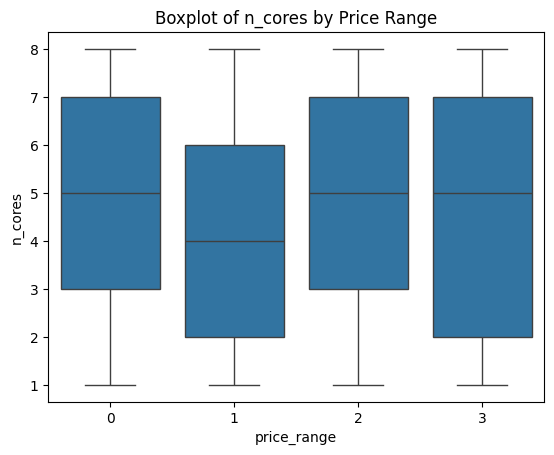

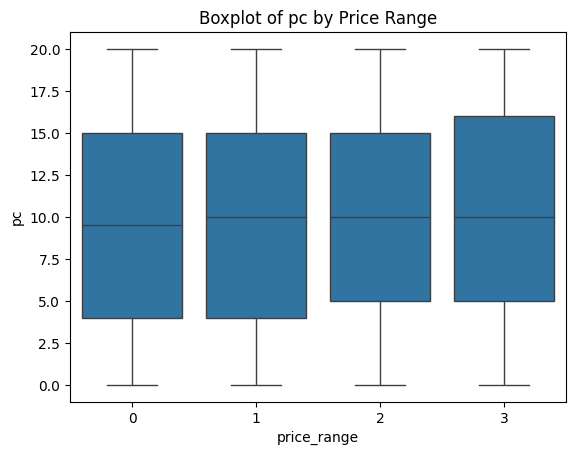

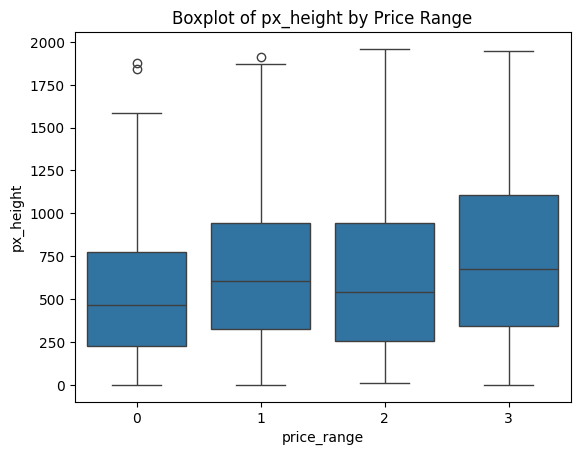

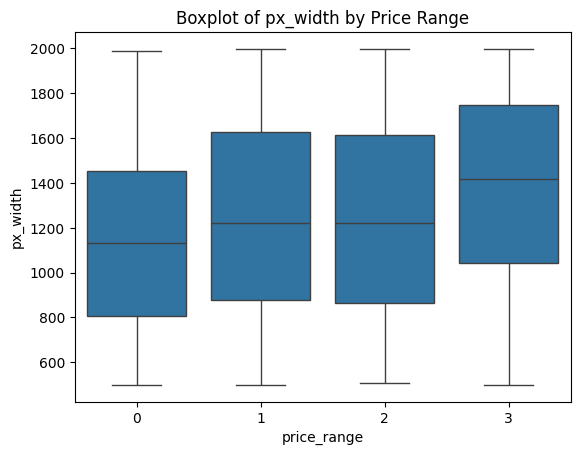

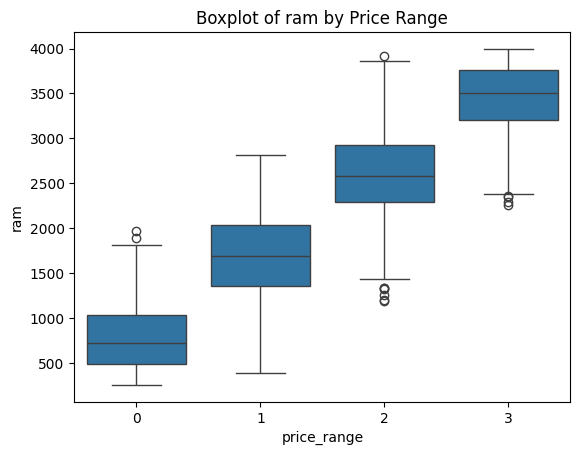

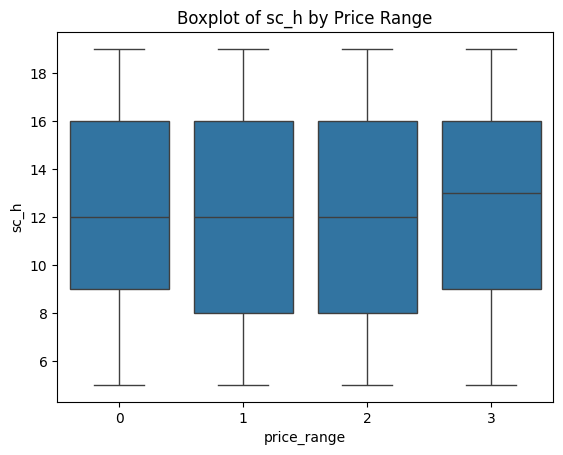

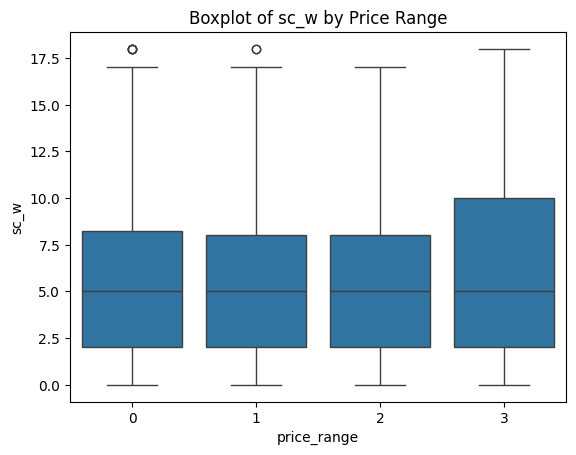

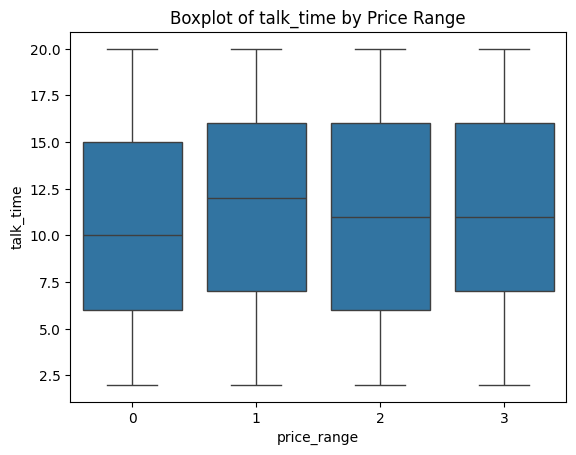

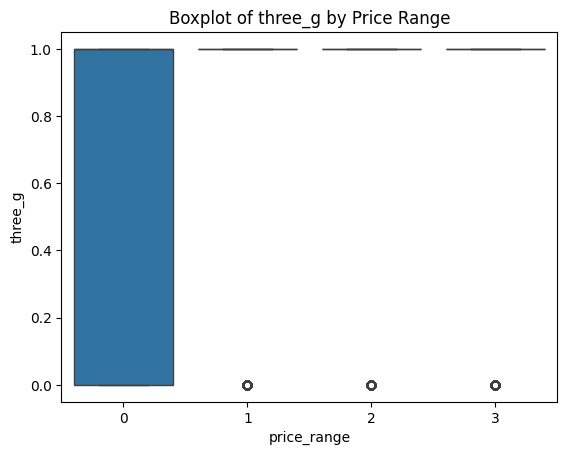

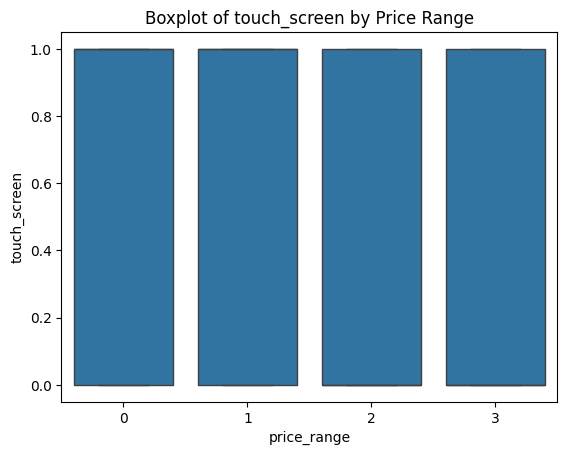

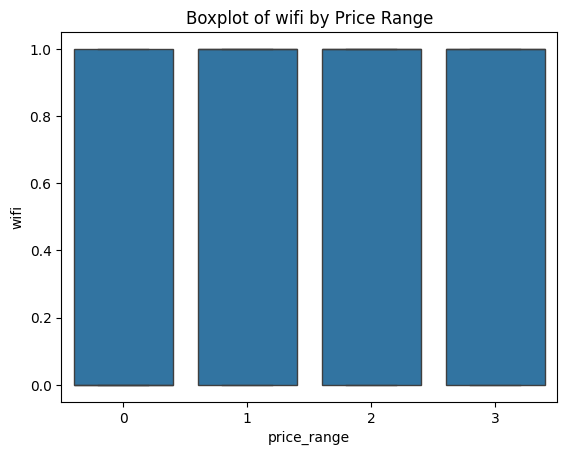

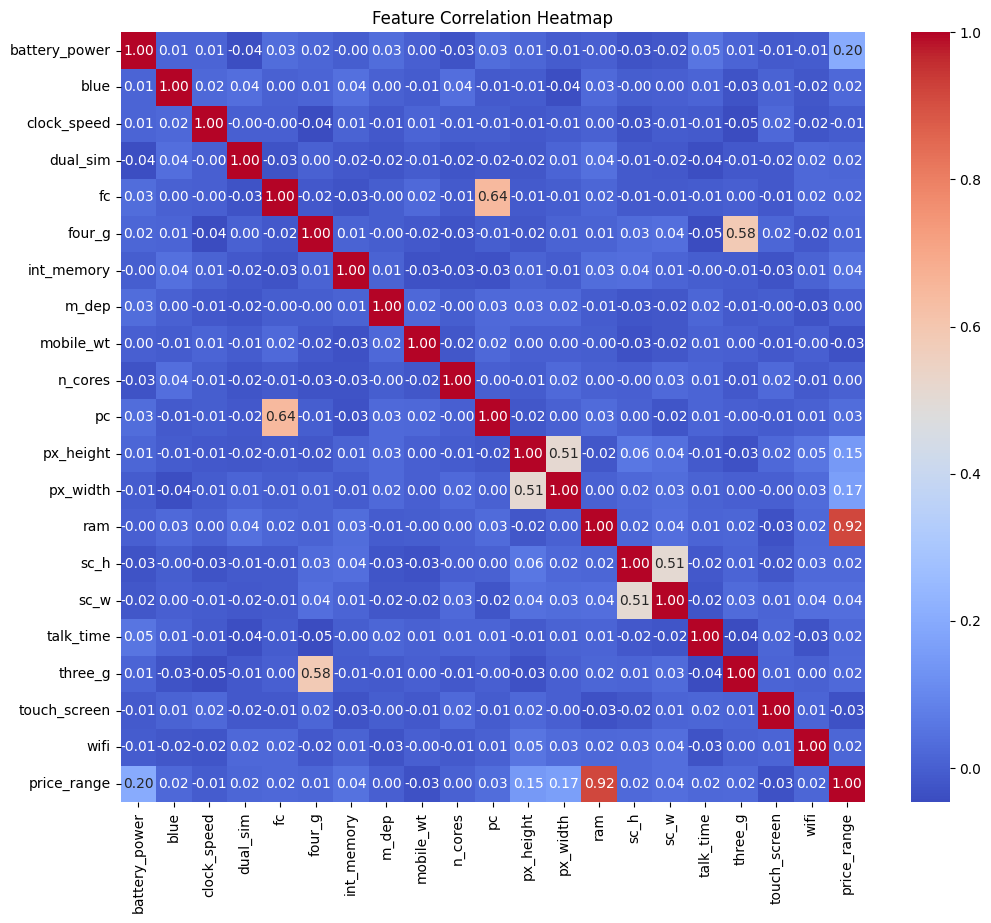

In [10]:

# Histogrammes pour observer la distribution des variables
for col in features:
    plt.figure()
    plt.hist(df[col], bins=30)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

# Pour comparer les distributions selon les classes de prix
for col in features:
    plt.figure()
    sns.boxplot(x="price_range", y=col, data=df)
    plt.title(f"Boxplot of {col} by Price Range")
    plt.show()

# Carte de chaleur pour visualiser les corrélations entre les variables
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()



### Interprétation – Histogrammes

- Les histogrammes montrent la **répartition des valeurs** pour chaque variable numérique.
- Ils permettent de détecter les **données asymétriques**, les **distributions normales** ou **biaisées**, ainsi que la **présence potentielle de valeurs extrêmes**.
- Par exemple, une variable très concentrée autour de certaines valeurs pourrait indiquer un **manque de variabilité** ou une **caractéristique commune** aux produits.



### Interprétation : Histogramme

- L'histogramme est utilisé pour observer la **distribution** d'une variable continue.
- Il permet de détecter une **asymétrie**, une **concentration des valeurs**, ou la **présence de valeurs extrêmes**.
- Cela est utile pour comprendre la nature des variables avant de faire des comparaisons ou modélisations.


In [11]:

print("\n--- Interprétations ---")
print("1. La mémoire RAM est fortement corrélée à la variable price_range et montre une séparation nette entre les différentes classes.")
print("2. La puissance de la batterie, les dimensions des pixels et la compatibilité 4G ont également une influence modérée sur le prix.")
print("3. Des fonctionnalités comme le Bluetooth, la double SIM et le WiFi ont un impact faible voire négligeable.")

print("\n--- Recommandations ---")
print("- Concentrer le marketing produit sur des appareils avec une RAM élevée et une haute résolution pour les segments premium.")
print("- Les téléphones d'entrée de gamme peuvent réduire la RAM et les caractéristiques de la caméra pour optimiser les coûts.")
print("- Envisager de supprimer ou de simplifier les fonctionnalités qui n'ont pas d'impact significatif sur la valeur perçue.")



--- Interprétations ---
1. La mémoire RAM est fortement corrélée à la variable price_range et montre une séparation nette entre les différentes classes.
2. La puissance de la batterie, les dimensions des pixels et la compatibilité 4G ont également une influence modérée sur le prix.
3. Des fonctionnalités comme le Bluetooth, la double SIM et le WiFi ont un impact faible voire négligeable.

--- Recommandations ---
- Concentrer le marketing produit sur des appareils avec une RAM élevée et une haute résolution pour les segments premium.
- Les téléphones d'entrée de gamme peuvent réduire la RAM et les caractéristiques de la caméra pour optimiser les coûts.
- Envisager de supprimer ou de simplifier les fonctionnalités qui n'ont pas d'impact significatif sur la valeur perçue.
